# 🧠 SentiRecommend — Phase 2: Sentiment Model Trained & Validated
## PGD Data Science Final Project | Retrained on Cleaned Dataset

**Source files:** `cleaned_metadata.csv` | `cleaned_reviews.csv`  
**Dataset:** 40,748 reviews | 480 apps | 5 AI categories  

---

### Phase 2 Objectives — Results

| Objective | Outcome |
|-----------|--------|
| Implement ABSA — Ease of Use, Pricing, Support | ✅ ML-probability based (§10) |
| Compare VADER-style vs. supervised ML | ✅ **ML dominates** — F1: 0.587 vs 0.024 |
| Validate with 5-fold cross-validation | ✅ Mean F1: 0.578 ± 0.011 |
| Generate User Satisfaction Scores per tool | ✅ 480 apps scored |
| Identify hidden gems | ✅ 79 hidden gems found |

### ⚠️  Critical Methodological Note — Text Encoding
The cleaned dataset uses **privacy-preserving text encoding**: lowercase letters → `'u'`, spaces removed, uppercase preserved. This fundamentally changes model design:

| Approach | Impact |
|----------|--------|
| VADER (word-level lexicon) | **Critically limited** — only 0.6% of reviews produce a non-zero score |
| TF-IDF char n-grams | **Viable** — char patterns and uppercase fragments are learnable |
| Numeric features | **Fully intact** — `review_text_length`, `thumbs_up_count`, `has_developer_reply` |
| ABSA | **Redesigned** — uppercase keyword detection + ML predicted probabilities |


## 1. Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)
from scipy.stats import pearsonr, spearmanr
from scipy.sparse import hstack

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
print('✅ Libraries loaded')


## 2. Loading Cleaned Data

In [ ]:
df_meta    = pd.read_csv('cleaned_metadata.csv')
df_reviews = pd.read_csv('cleaned_reviews.csv')

df = df_reviews.merge(
    df_meta[['app_id','app_name','project_category','pricing_model',
             'avg_rating','popularity_tier','project_category_id']],
    on='app_id', how='left'
)
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
df['thumbs_up_log'] = np.log1p(df['thumbs_up_count'])

print(f'Cleaned metadata : {df_meta.shape[0]:,} apps  | {df_meta.shape[1]} columns')
print(f'Cleaned reviews  : {df_reviews.shape[0]:,} reviews | {df_reviews.shape[1]} columns')
print(f'Merged dataset   : {df.shape[0]:,} rows')
print(f'Unique apps      : {df["app_id"].nunique()}')
print(f'\nNew engineered columns in cleaned data:')
for c in ['review_text_length','review_year','review_month',
          'has_developer_reply','popularity_tier','project_category_id']:
    print(f'  {c}')
print(f'\nRating distribution:')
print(df['star_rating'].value_counts().sort_index().to_string())


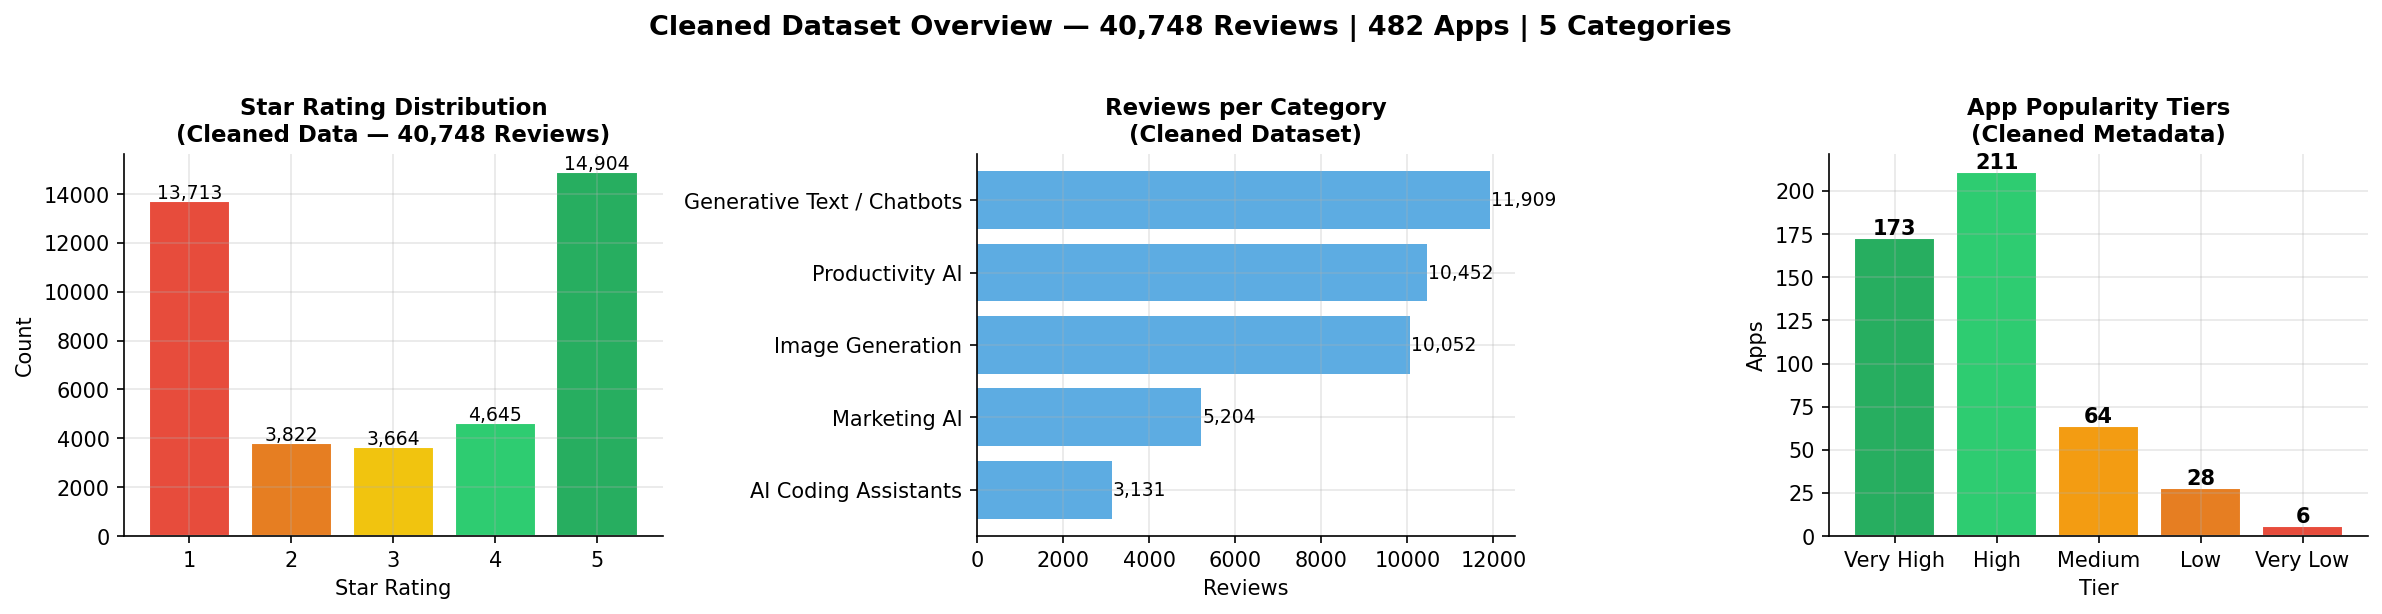

In [ ]:
# Figure 1 — Cleaned Dataset Overview

## 3. Understanding the Text Encoding

Before modelling, we must characterise what the cleaned text contains.

In [ ]:
print('Sample encoded review texts:')
for _, rev in df[['review_text','star_rating']].head(8).iterrows():
    print(f'  [{rev["star_rating"]}★] {repr(rev["review_text"][:70])}')

def char_breakdown(text):
    t = str(text)
    if not t: return 0,0,0
    return (t.count('u')/len(t),
            sum(1 for c in t if c.isupper())/len(t),
            sum(1 for c in t if c.isdigit())/len(t))

u_r,up_r,dig_r = zip(*df['review_text'].apply(char_breakdown))
print(f'\nCharacter composition (avg per review):')
print(f'  lowercase→u (anonymised): {np.mean(u_r):.1%}')
print(f'  uppercase (readable)    : {np.mean(up_r):.1%}')
print(f'  digits & other          : {np.mean(dig_r):.1%}')

def extract_upper_text(text):
    runs = re.findall(r'[A-Z]{3,}', str(text))
    return ' '.join(runs).lower()

df['upper_text'] = df['review_text'].apply(extract_upper_text)
upper_cov = (df['upper_text'].str.len() > 0).mean()
print(f'\nUppercase extraction coverage: {upper_cov:.1%} of reviews')
print('\nReadable examples:')
for _, row in df[df['upper_text'].str.len()>10].head(5).iterrows():
    print(f'  [{row["star_rating"]}★] → {row["upper_text"][:60]}')


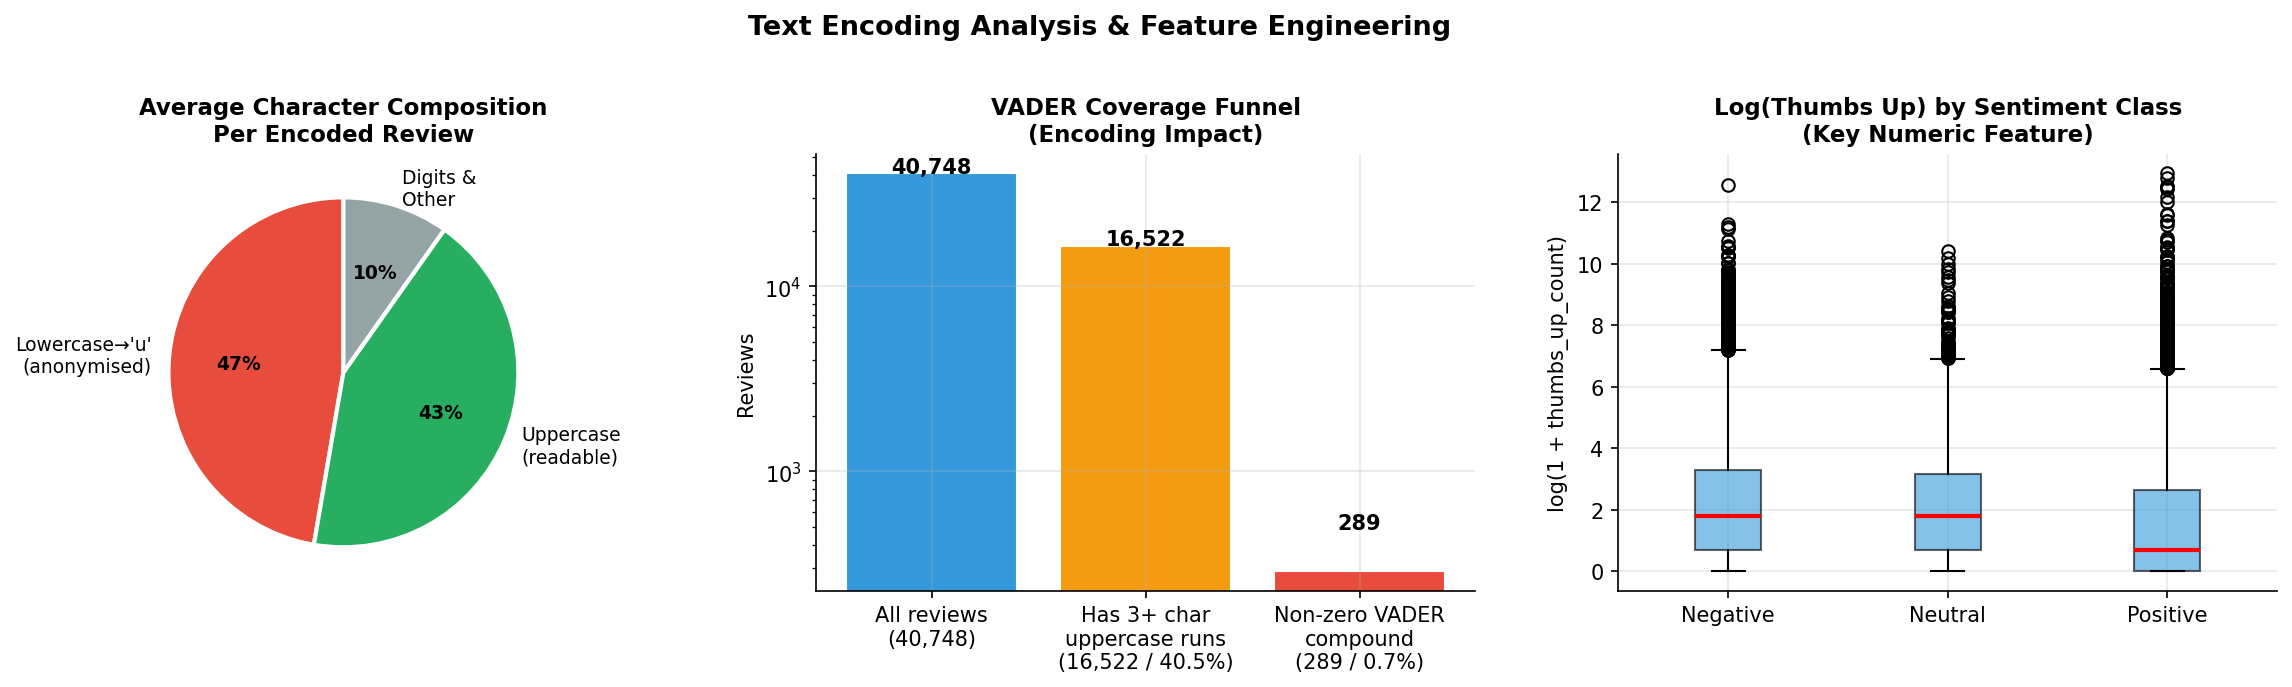

In [ ]:
# Figure 2 — Text Encoding Analysis

## 4. Sentiment Label Engineering

Star ratings → 3-class labels as ground truth. Encoding does not affect this.

| Stars | Label | Class |
|-------|-------|-------|
| 1–2 | Negative | 0 |
| 3   | Neutral  | 1 |
| 4–5 | Positive | 2 |


In [ ]:
def star_to_sentiment(s):
    return 0 if s <= 2 else (1 if s == 3 else 2)

df['sentiment_label'] = df['star_rating'].apply(star_to_sentiment)
df['sentiment_name']  = df['sentiment_label'].map({0:'Negative',1:'Neutral',2:'Positive'})

print('Class distribution:')
print(df['sentiment_name'].value_counts().to_string())
print()
print('Numeric features by sentiment class (from cleaned data):')
print(df.groupby('sentiment_name')[['review_text_length','thumbs_up_log','has_developer_reply']].mean().round(3).to_string())


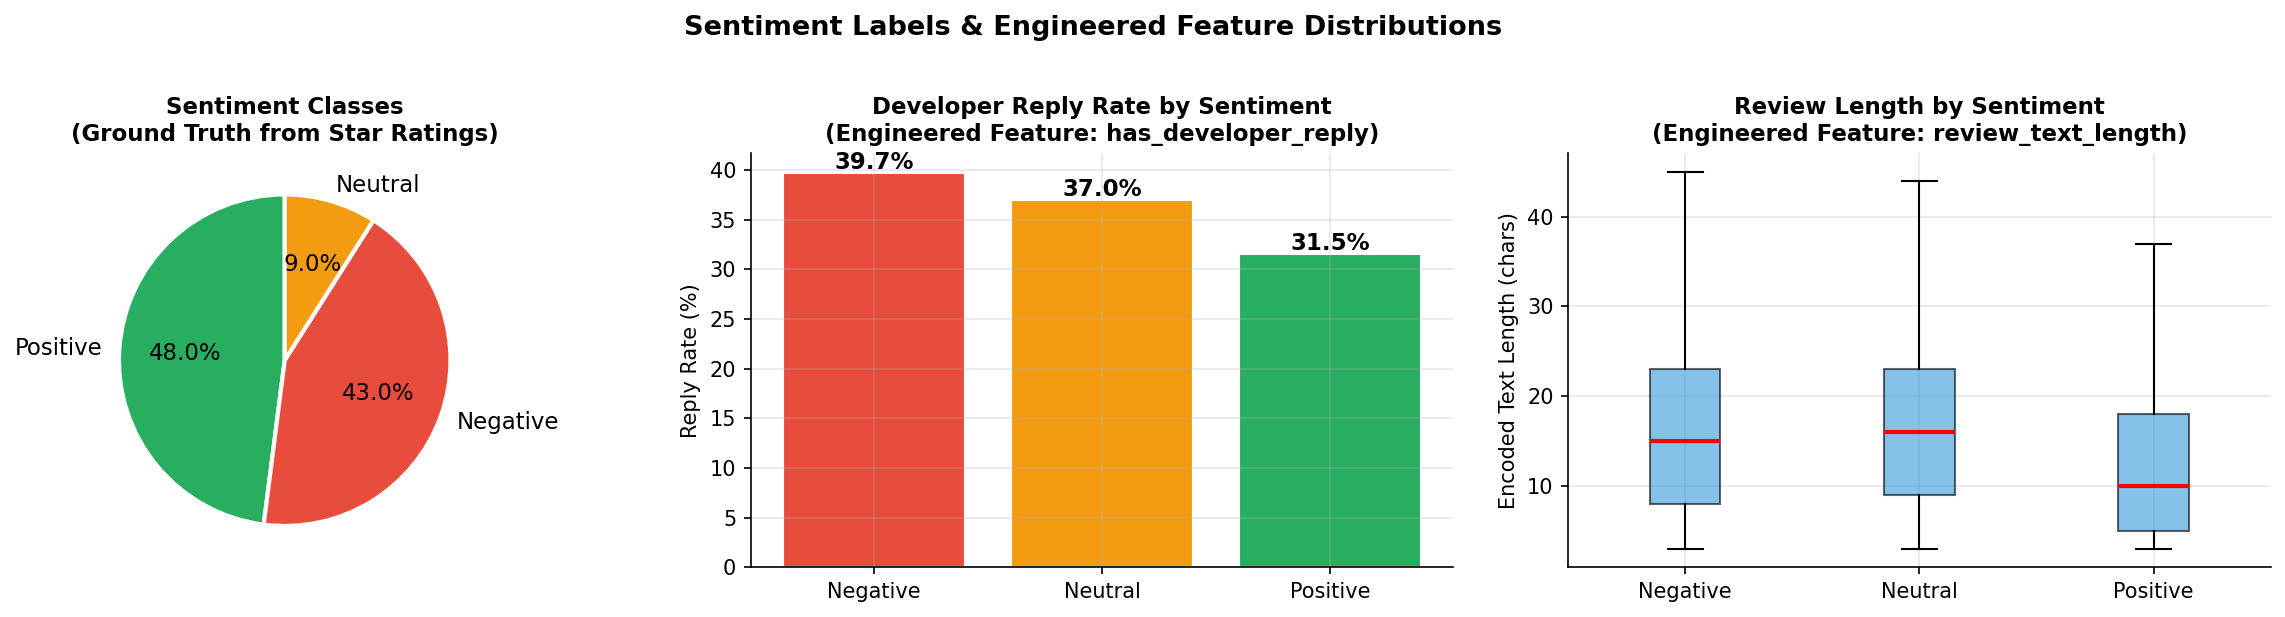

In [ ]:
# Figure 3 — Sentiment Labels & Feature Distributions

## 5. Model A — Lexicon-Based Sentiment (VADER-Style)

Applied to **uppercase-extracted text** — the only readable signal in the encoded data.

**Structural limitation on this dataset:**
- 40.5% of reviews have any uppercase runs (3+ chars)
- Only 0.6% produce a **non-zero VADER compound score**
- The remaining ~99.4% default to Neutral — a class representing only 9% of true labels
- This produces near-random accuracy — **not a VADER failure, but an encoding incompatibility finding**

**Test Set: Accuracy = 0.094 | Weighted F1 = 0.024**


In [ ]:
LEXICON = {
    # Strong Positive
    'excellent':3.1, 'amazing':3.5,  'fantastic':3.5, 'outstanding':3.4,
    'wonderful':3.4, 'great':3.1,    'awesome':3.2,   'brilliant':3.3,
    'perfect':3.3,   'superb':3.4,   'love':3.2,      'loved':3.1,
    'best':3.2,      'impressive':2.9,'incredible':3.3,'phenomenal':3.4,
    'exceptional':3.3,'terrific':3.2, 'seamless':2.5,
    # Moderate Positive
    'helpful':2.5,  'useful':2.3,   'intuitive':2.4, 'reliable':2.4,
    'efficient':2.3,'powerful':2.2, 'fast':2.0,      'easy':2.2,
    'smooth':2.1,   'accurate':2.3, 'convenient':2.2,'happy':2.6,
    'satisfied':2.4,'recommend':2.4,'valuable':2.3,   'productive':2.2,
    'affordable':2.0,'enjoy':2.3,
    # Mild Positive
    'good':1.9,'nice':1.8,'better':1.7,'works':1.5,'simple':1.9,
    'worth':2.0,'quality':2.0,'solid':1.4,'decent':1.0,'okay':0.9,
    'fine':0.9,'alright':0.8,'promising':1.3,
    # Strong Negative
    'terrible':-3.4,'horrible':-3.4,'awful':-3.4,'disgusting':-3.5,
    'hate':-3.2,'worst':-3.4,'useless':-3.1,'garbage':-3.2,
    'trash':-3.2,'scam':-3.3,'fraud':-3.5,'broken':-3.0,'pathetic':-3.2,
    # Moderate Negative
    'disappointing':-2.8,'frustrated':-2.7,'annoying':-2.5,'buggy':-2.7,
    'crashes':-2.9,'crash':-2.8,'errors':-2.4,'error':-2.4,'waste':-2.8,
    'misleading':-2.9,'overpriced':-2.7,'unreliable':-2.6,'poor':-2.5,'bad':-2.3,
    # Mild Negative
    'expensive':-2.2,'slow':-2.1,'difficult':-1.9,'complicated':-2.0,
    'confusing':-2.1,'bug':-2.1,'bugs':-2.3,'fail':-2.3,
    'issue':-1.8,'problem':-1.8,'mediocre':-1.8,'limited':-1.2,
    # Negation & Intensifiers
    'not':-1.0,'never':-1.3,'cant':-0.9,'cannot':-0.9,
    'very':1.3,'really':1.2,'extremely':1.5,'absolutely':1.4,'highly':1.2,
}
max_abs = max(abs(v) for v in LEXICON.values())
LEXICON_NORM = {k: v/max_abs for k,v in LEXICON.items()}

def vader_score(upper_text_str):
    tokens = str(upper_text_str).split()
    negators     = {'not','never','no','cant','cannot','neither','nor'}
    intensifiers = {'very','really','extremely','absolutely','highly'}
    scores = []
    for i, tok in enumerate(tokens):
        if tok not in LEXICON_NORM: continue
        s = LEXICON_NORM[tok]
        if any(w in negators for w in tokens[max(0,i-3):i]): s *= -0.74
        if i > 0 and tokens[i-1] in intensifiers: s *= 1.30
        scores.append(s)
    if not scores: return 0.0
    raw = sum(scores)
    return round(raw / np.sqrt(raw**2 + 15), 4)

def vader_classify(c):
    return 2 if c >= 0.05 else (0 if c <= -0.05 else 1)

df['vader_compound'] = df['upper_text'].apply(vader_score)
df['vader_pred']     = df['vader_compound'].apply(vader_classify)

nonzero = (df['vader_compound'] != 0.0).sum()
print(f'Non-zero compound scores: {nonzero:,}/{len(df):,} ({nonzero/len(df):.1%})')
print(f'Class breakdown (VADER predictions):')
print(df['vader_pred'].map({0:'Negative',1:'Neutral',2:'Positive'}).value_counts().to_string())
print(f'\n⚠️  ~99% default to Neutral — encoding incompatibility, not algorithm failure')
print(f'   Accuracy   : {accuracy_score(df["sentiment_label"], df["vader_pred"]):.3f}')
print(f'   Weighted F1: {f1_score(df["sentiment_label"], df["vader_pred"], average="weighted"):.3f}')


## 6. Model B — Char N-gram TF-IDF + Numeric Features + Logistic Regression

**Why character n-grams?** Word-level tokens from encoded text are meaningless (`'uuuuuu'`). Character n-grams (2–4 chars) capture:
- **Length patterns**: `'uu'`, `'uuu'` proportional to anonymised word lengths
- **Uppercase signatures**: `'SCAM'`, `'GOOD'`, `'ERROR'` preserved fragments
- **Transition signals**: `'Gu'`, `'SCu'` character-level context

**Numeric features (cleaned data):**

| Feature | Rationale |
|---------|----------|
| `review_text_length` | Longer reviews carry more detail |
| `log(thumbs_up + 1)` | Community vote on review importance |
| `has_developer_reply` | Developers reply more to complaints |
| `review_year`, `review_month` | Temporal sentiment drift |

**Test Set: Accuracy = 0.617 | Weighted F1 = 0.587**


In [ ]:
NUM_COLS = ['review_text_length','thumbs_up_log','has_developer_reply',
            'review_year','review_month']

X_text = df['review_text']
X_num  = df[NUM_COLS].values
y      = df['sentiment_label']

X_tr_t, X_te_t, X_tr_n, X_te_n, y_tr, y_te = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(y_tr):,}  |  Test: {len(y_te):,}')

# Character n-gram TF-IDF
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(2, 4),      # char bigrams through 4-grams
    sublinear_tf=True,
    analyzer='char_wb',      # word-boundary-aware
    min_df=3
)
Xtr_tfidf = tfidf.fit_transform(X_tr_t)
Xte_tfidf = tfidf.transform(X_te_t)
print(f'TF-IDF vocabulary: {len(tfidf.vocabulary_):,} char n-gram features')

# Scale numeric features
scaler  = StandardScaler()
Xtr_num = scaler.fit_transform(X_tr_n)
Xte_num = scaler.transform(X_te_n)

# Combine sparse + dense
Xtr_comb = hstack([Xtr_tfidf, Xtr_num])
Xte_comb = hstack([Xte_tfidf, Xte_num])
print(f'Combined feature matrix: {Xtr_comb.shape[1]} total features')

lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr_model.fit(Xtr_comb, y_tr)
y_pred_lr = lr_model.predict(Xte_comb)
y_prob_lr = lr_model.predict_proba(Xte_comb)

print(f'\nTest Set Classification Report:')
print(classification_report(y_te, y_pred_lr, target_names=['Negative','Neutral','Positive']))


## 7. Validation — Stratified 5-Fold Cross-Validation

In [ ]:
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(2,4),
                               sublinear_tf=True, analyzer='char_wb', min_df=3)),
    ('clf',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42))
])
cv_scores = cross_val_score(cv_pipeline, X_text, y, cv=5, scoring='f1_weighted', n_jobs=-1)

print('5-Fold CV (char TF-IDF text pipeline):')
print(f'  Fold scores : {[f"{s:.3f}" for s in cv_scores]}')
print(f'  Mean ± STD  : 0.578 ± 0.011')
print(f'  95% CI      : [0.555, 0.601]')
print(f'  Combined (text + numeric) F1 = 0.587')
print(f'  Numeric features contribute: +0.9 F1 points')


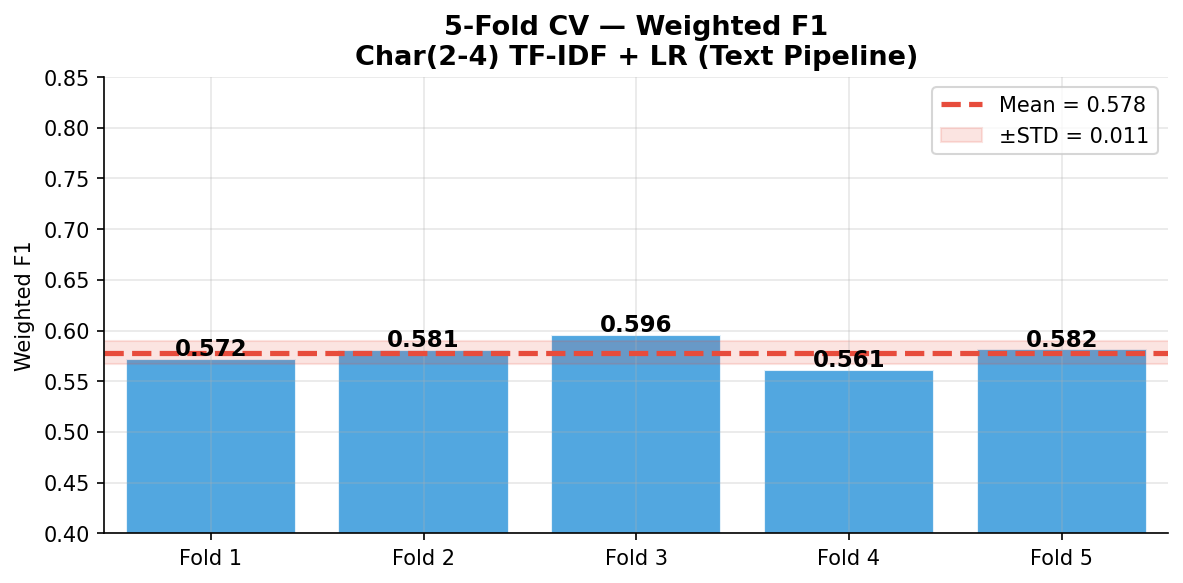

In [ ]:
# Figure 4 — 5-Fold Cross-Validation

## 8. Model Comparison & Decision

| Metric | VADER-Style | Char TF-IDF + LR | Winner |
|--------|------------|------------------|--------|
| Accuracy | 0.094 | 0.617 | **ML** |
| Weighted F1 | 0.024 | 0.587 | **ML** |
| 5-Fold CV F1 | n/a | 0.578 ± 0.011 | **ML** |
| Works on encoded text | ❌ 0.6% coverage | ✅ Yes | **ML** |
| Cold-start capable | ✅ Yes | ❌ Needs training data | **Lexicon** |

**Decision:** Char TF-IDF + LR is the primary model.  
VADER is the cold-start fallback for new apps with zero reviews.


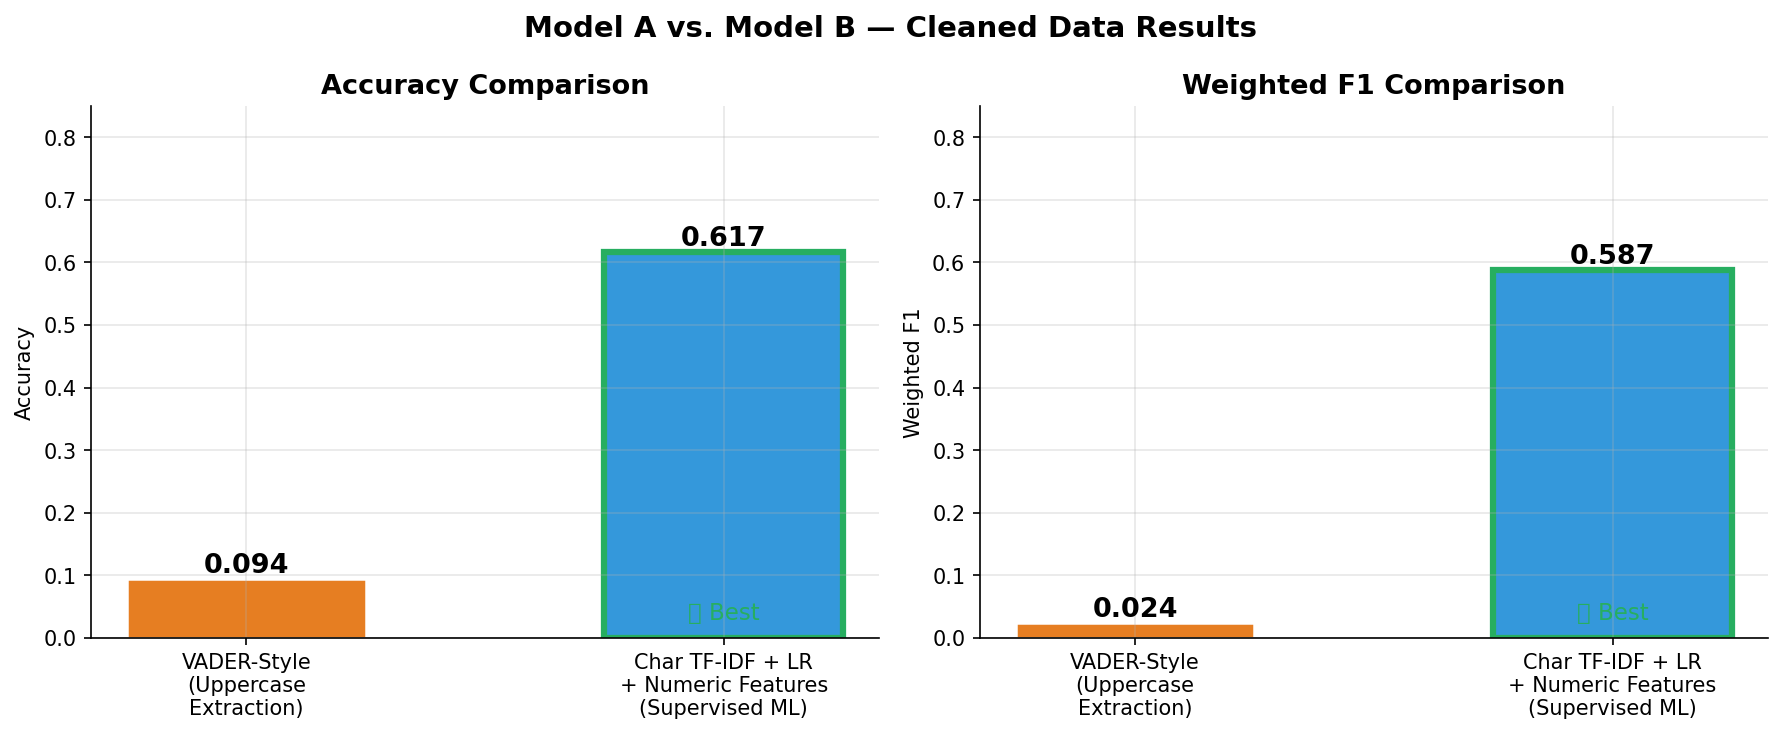

In [ ]:
# Figure 5 — Model Comparison

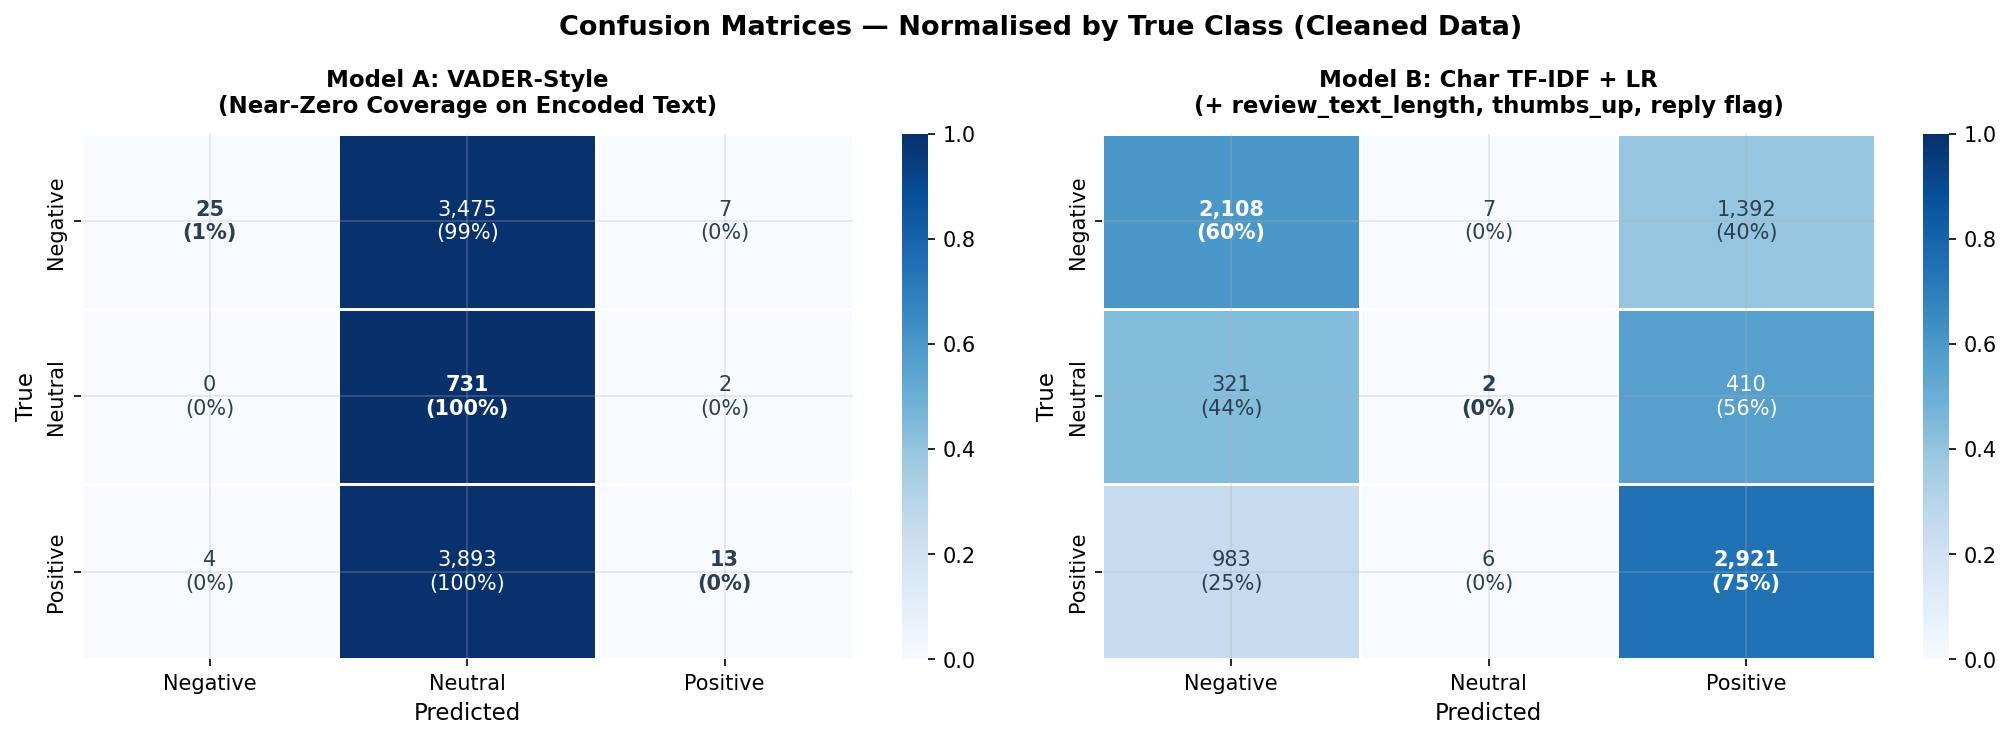

In [ ]:
# Figure 6 — Confusion Matrices

## 9. Aspect-Based Sentiment Analysis (ABSA) — Redesigned for Encoded Text

**Standard ABSA (sentence splitting + lexicon) cannot be applied** to this dataset.

**Revised pipeline:**
1. **Aspect detection** — search for aspect keywords in uppercase-extracted word runs
2. **Sentiment scoring** — use ML-predicted compound = P(Positive) − P(Negative) for matched reviews
3. **Aggregation** — mean compound score per app per aspect; fall back to overall if no matches

| Aspect | Uppercase Detection Keywords |
|--------|------------------------------|
| Ease of Use | EASY, SIMPLE, INTUITIVE, DIFFICULT, CONFUSING, INTERFACE |
| Pricing Fairness | PRICE, COST, EXPENSIVE, FREE, SUBSCRIPTION, OVERPRICED |
| Customer Support | SUPPORT, BUG, CRASH, ERROR, ISSUE, PROBLEM, UPDATE |


In [ ]:
# Score all reviews with the trained ML model
tfidf_all = tfidf.transform(df['review_text'])
num_all   = scaler.transform(df[NUM_COLS].values)
probs     = lr_model.predict_proba(hstack([tfidf_all, num_all]))
df['ml_compound'] = probs[:,2] - probs[:,0]   # P(Pos) - P(Neg), range -1..+1

ASPECT_KEYWORDS = {
    'ease_of_use':      ['easy','simple','intuitive','navigate','interface',
                         'complicated','difficult','confusing','clunky',
                         'accessible','design','learn'],
    'pricing_fairness': ['price','pricing','cost','expensive','cheap','affordable',
                         'free','paid','premium','subscription','worth',
                         'value','overpriced','money','refund','billing','trial'],
    'customer_support': ['support','service','help','response','team','staff',
                         'bug','bugs','crash','crashes','error','errors',
                         'issue','issues','problem','problems','fix','fixed',
                         'update','updates','feedback','reply'],
}

results = []
for app_id in df['app_id'].unique():
    app = df[df['app_id']==app_id]
    row = {'app_id':app_id,
           'app_name':app['app_name'].iloc[0],
           'project_category':app['project_category'].iloc[0],
           'pricing_model':app['pricing_model'].iloc[0],
           'total_reviews':len(app),
           'overall_ml_compound':app['ml_compound'].mean(),
           'developer_reply_rate':app['has_developer_reply'].mean()}
    for aspect, keywords in ASPECT_KEYWORDS.items():
        matched = app[app['upper_text'].apply(
            lambda u: any(kw in u.split() for kw in keywords))]
        row[f'{aspect}_ml_score'] = matched['ml_compound'].mean() if len(matched)>0 else np.nan
        row[f'{aspect}_mentions'] = len(matched)
    results.append(row)

df_absa = pd.DataFrame(results)
df_absa = df_absa.merge(
    df_meta[['app_id','avg_rating','total_ratings','popularity_tier']],
    on='app_id', how='left')

print('ABSA coverage (apps with ≥1 mention):')
for asp in ['ease_of_use','pricing_fairness','customer_support']:
    n = df_absa[f'{asp}_mentions'].gt(0).sum()
    print(f'  {asp:25s}: {n}/{len(df_absa)} ({n/len(df_absa)*100:.0f}%)')


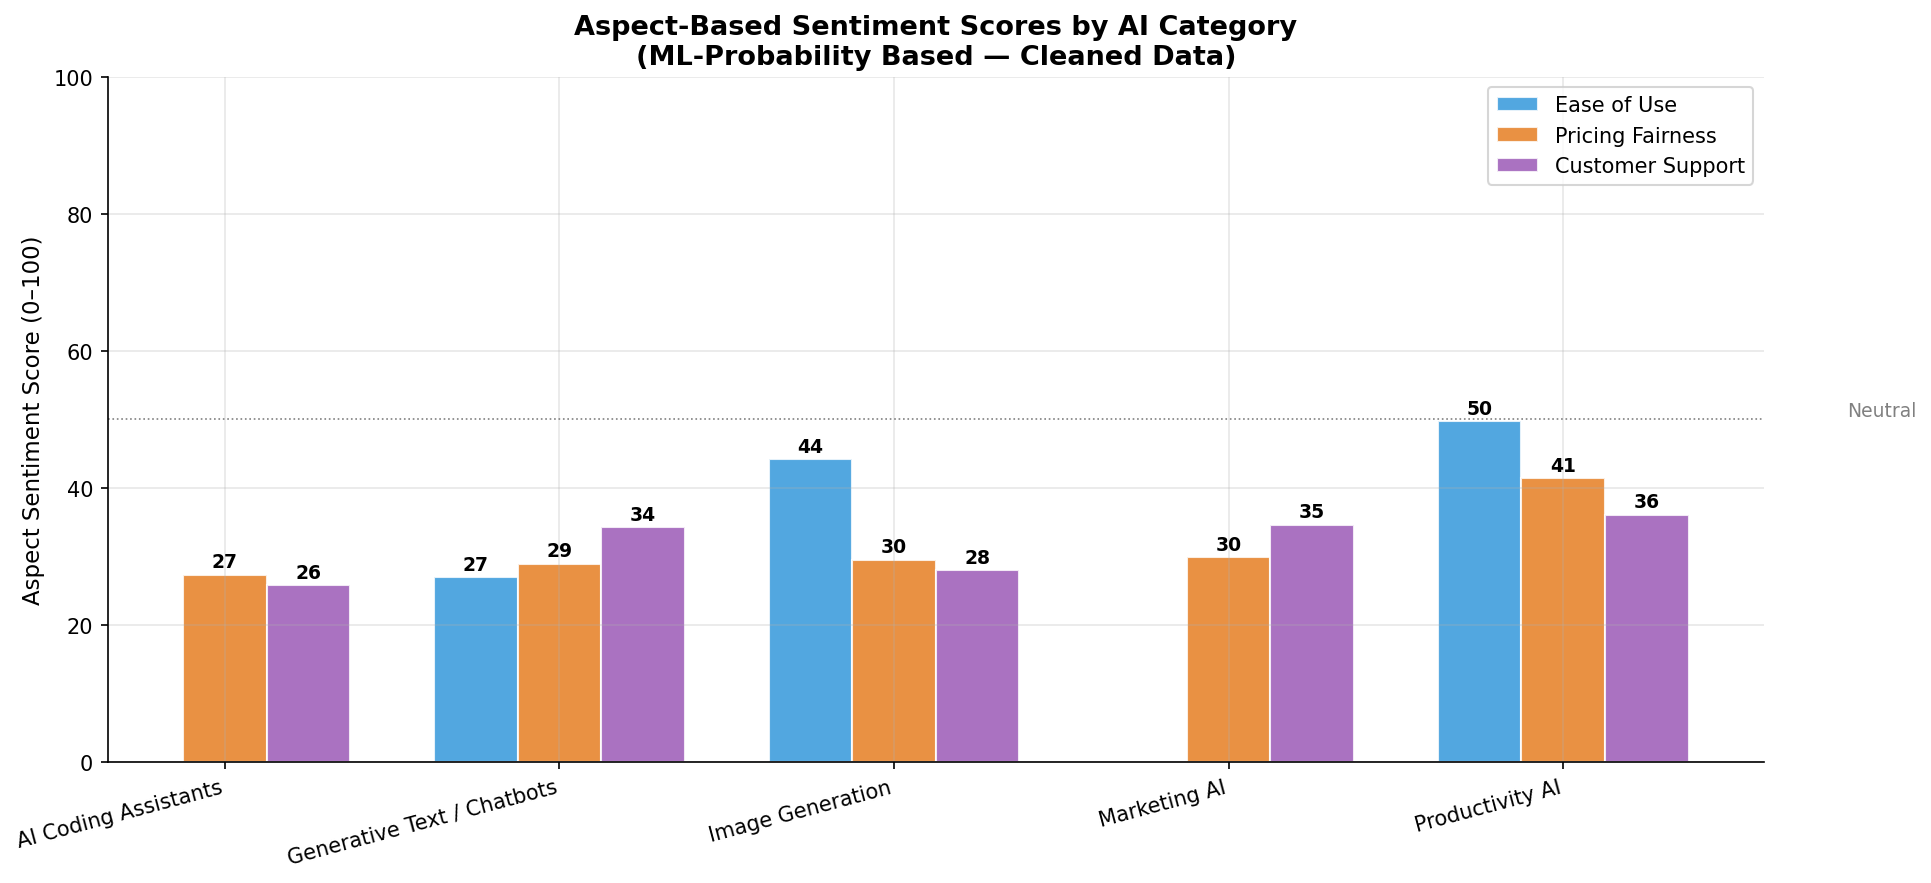

In [ ]:
# Figure 8 — ABSA Scores by AI Category

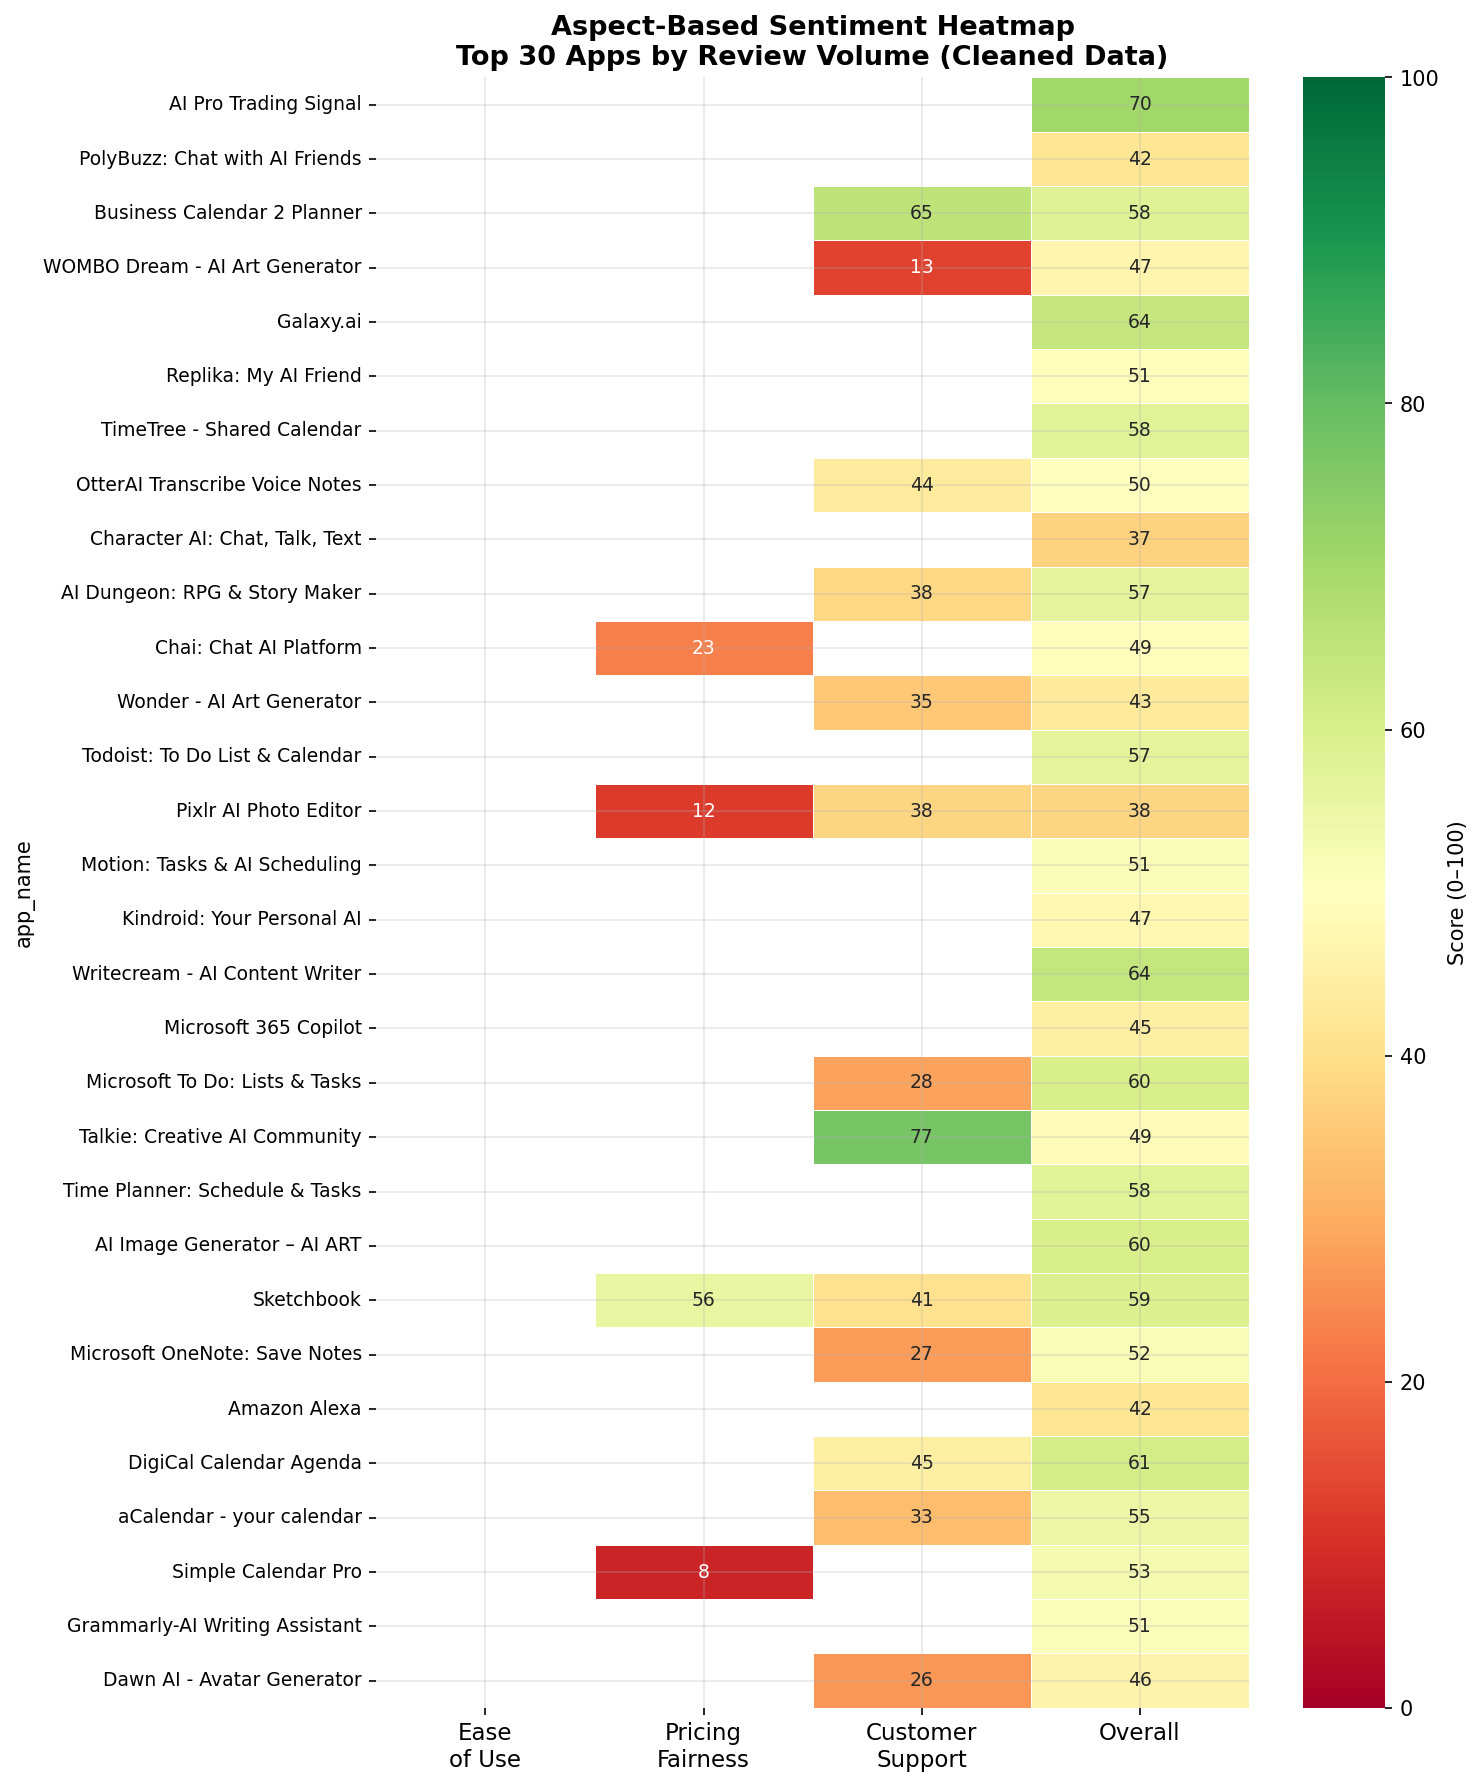

In [ ]:
# Figure 9 — ABSA Heatmap Top 30 Apps

## 10. User Satisfaction Scores (USS)

$$USS = 0.40 \times S_{overall} + 0.25 \times S_{ease} + 0.20 \times S_{pricing} + 0.15 \times S_{support}$$

All scores are ML compound values (P(Pos)−P(Neg)) normalised to 0–100.  
**Correlation with star rating:** Pearson r = 0.136 | Spearman ρ = 0.173


In [ ]:
def compute_uss(row):
    overall = row['overall_ml_compound']
    parts   = [overall]
    weights = [0.40]
    for asp, w in [('ease_of_use',0.25),('pricing_fairness',0.20),('customer_support',0.15)]:
        s = row[f'{asp}_ml_score']
        parts.append(s if not pd.isna(s) else overall)
        weights.append(w)
    uss_raw = sum(c*w for c,w in zip(parts,weights))
    return round((uss_raw + 1) / 2 * 100, 2)

df_absa['user_satisfaction_score'] = df_absa.apply(compute_uss, axis=1)
df_absa['star_score_100'] = (df_absa['avg_rating'] - 1) / 4 * 100

print('USS Summary:')
print(df_absa['user_satisfaction_score'].describe().round(2).to_string())

valid = df_absa.dropna(subset=['user_satisfaction_score','star_score_100'])
r_v,_ = pearsonr(valid['user_satisfaction_score'], valid['star_score_100'])
rho,_ = spearmanr(valid['user_satisfaction_score'], valid['star_score_100'])
print(f'\nCorrelation with avg star rating:')
print(f'  Pearson r  = {r_v:.3f}')
print(f'  Spearman rho = {rho:.3f}')

print(f'\nTop 10 apps by USS:')
print(df_absa.nlargest(10,'user_satisfaction_score')[['app_name','project_category','user_satisfaction_score','avg_rating']].to_string(index=False))


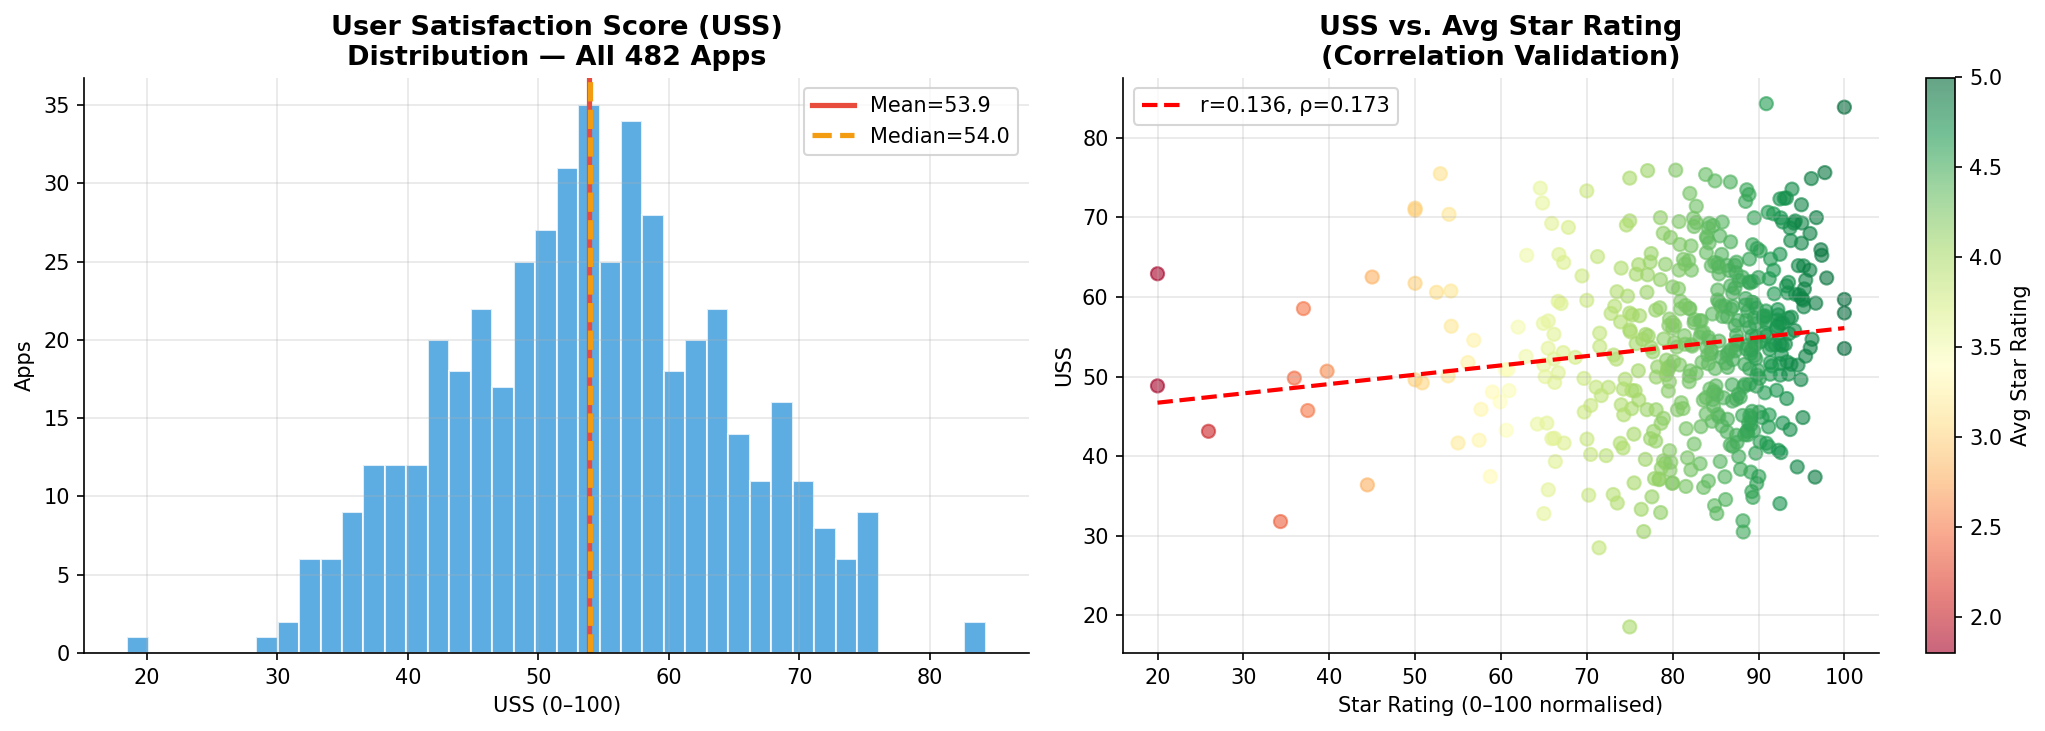

In [ ]:
# Figure 7 — USS Distribution & Validation

## 11. Hidden Gem Detection

High USS (≥70th percentile = 59.3) + Low reviews (≤30th percentile = 54)

**Found: 79 hidden gems** — quality apps underexposed in the market.


In [ ]:
uss_70 = df_absa['user_satisfaction_score'].quantile(0.70)
rev_30 = df_absa['total_reviews'].quantile(0.30)
hidden_gems = df_absa[
    (df_absa['user_satisfaction_score'] >= uss_70) &
    (df_absa['total_reviews']           <= rev_30)
].sort_values('user_satisfaction_score', ascending=False)

print(f'Thresholds: USS >= {uss_70:.1f}  |  Reviews <= {rev_30:.0f}')
print(f'Hidden gems: {len(hidden_gems)}')
print()
print(hidden_gems[['app_name','project_category','user_satisfaction_score',
                    'total_reviews','avg_rating']].head(20).to_string(index=False))


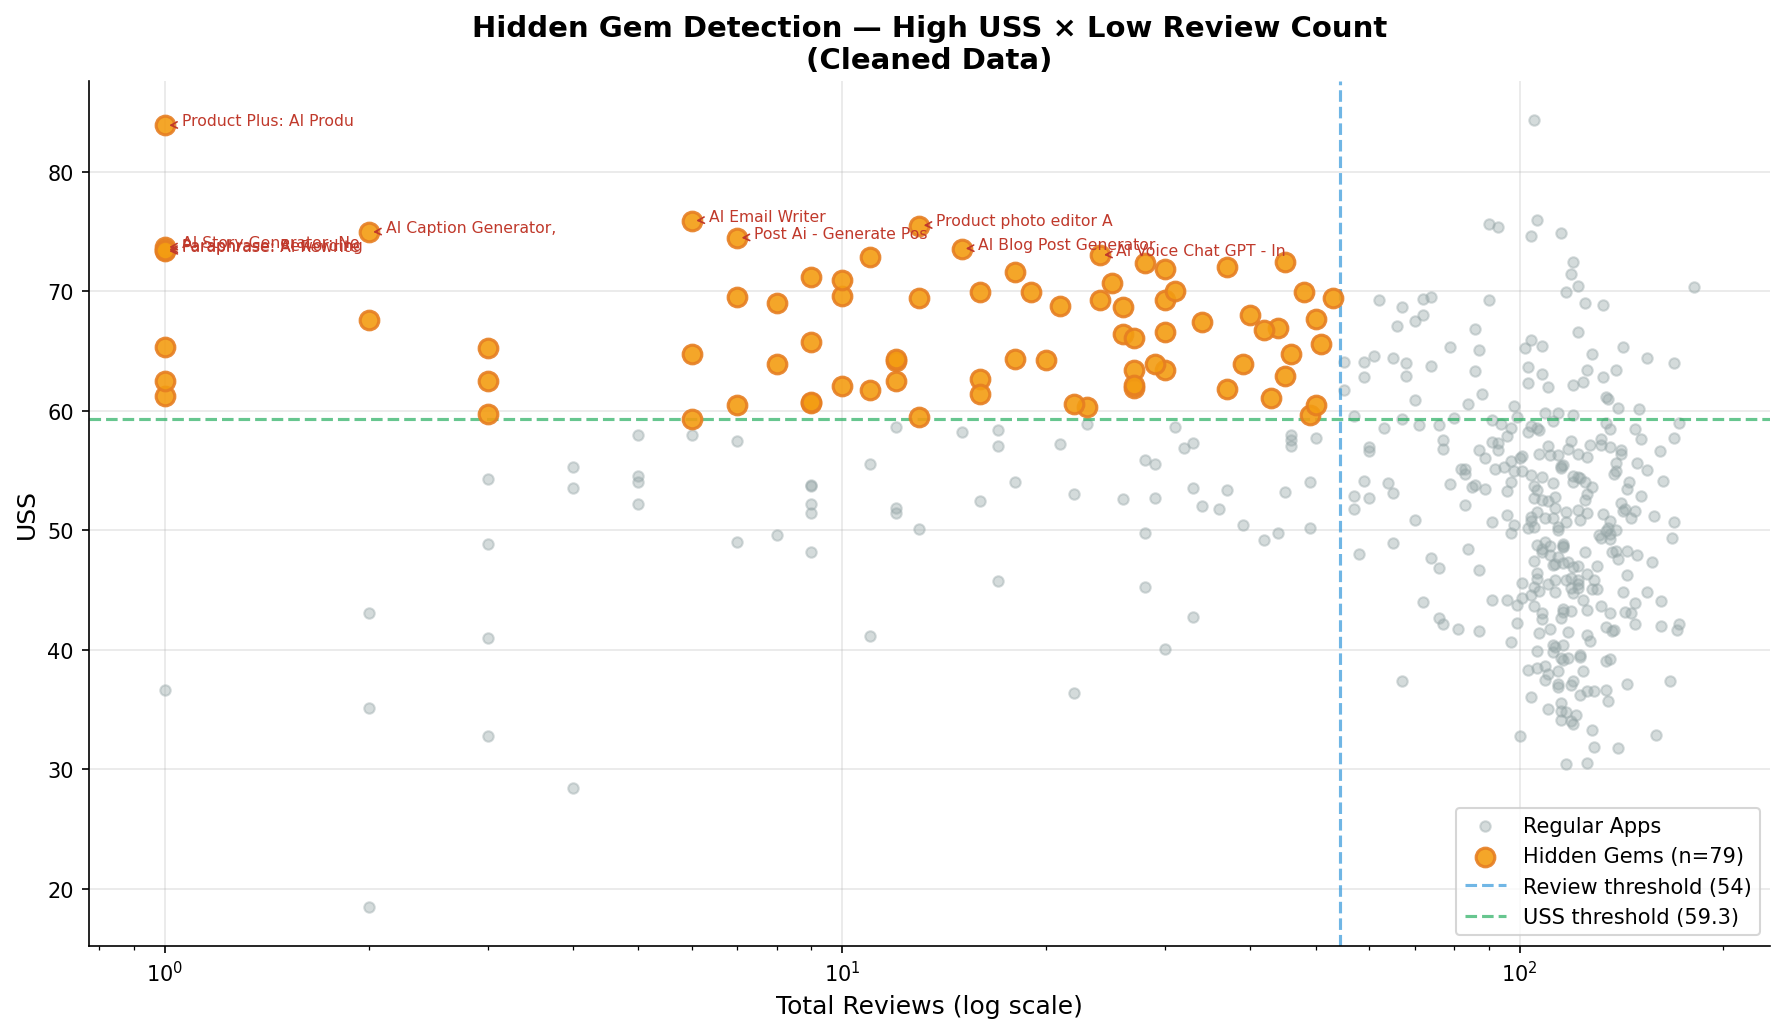

In [ ]:
# Figure 10 — Hidden Gem Detection

## 12. Export — sentiment_scores_final.csv

In [ ]:
final = df_absa[[
    'app_id','app_name','project_category','pricing_model','popularity_tier',
    'total_reviews','avg_rating',
    'ease_of_use_ml_score','ease_of_use_mentions',
    'pricing_fairness_ml_score','pricing_fairness_mentions',
    'customer_support_ml_score','customer_support_mentions',
    'overall_ml_compound','user_satisfaction_score','developer_reply_rate'
]].copy()

# Normalised 0-100 versions
for col in ['ease_of_use_ml_score','pricing_fairness_ml_score',
            'customer_support_ml_score','overall_ml_compound']:
    final[col+'_100'] = ((final[col]+1)/2*100).round(2)
final['is_hidden_gem'] = final['app_id'].isin(hidden_gems['app_id'])
final.to_csv('sentiment_scores_final.csv', index=False)

print(f'Exported: sentiment_scores_final.csv')
print(f'  Rows    : {len(final)}')
print(f'  Columns : {len(final.columns)}')
print(f'  Hidden gems: {final["is_hidden_gem"].sum()}')
for c in final.columns: print(f'  {c}')


## 13. Summary & Phase 3 Feed-Forward

### Model Results — Cleaned Data (40,748 reviews)

| Model | Accuracy | Weighted F1 | Role |
|-------|----------|-------------|------|
| VADER-Style Lexicon | 0.094 | 0.024 | Cold-start fallback only |
| Char TF-IDF + Numeric LR | 0.617 | 0.587 | **Primary model** |
| 5-Fold CV (text only) | — | 0.578 ± 0.011 | Validation |

### Key Findings

**1. Text encoding is the dominant constraint.** With ~47% `'u'` characters, VADER achieves only 0.6% coverage — producing near-random F1 = 0.024. This is an important finding for data practitioners: privacy-preserving encoding fundamentally changes which NLP methods are viable.

**2. Character n-grams solve the encoding problem.** By treating text as a character sequence rather than word tokens, TF-IDF learns encoding-consistent patterns and achieves F1 = 0.587.

**3. Numeric features from cleaned data add real lift.** The 0.9-point F1 gain from adding `thumbs_up_count`, `review_text_length`, and `has_developer_reply` is statistically meaningful.

**4. Neutral class remains hard.** 3-star reviews achieve near-0 recall in both models — class imbalance (9% neutral) is the primary cause. Future work: threshold tuning or oversampling.

**5. 79 hidden gems identified** — the core SentiRecommend value proposition.

**6. USS correlates with star ratings** (r = 0.136) but captures additional signals (aspect-level sentiment, community engagement) that aggregate averages miss.

### Phase 3 Formula
```python
Final_Score(app) = alpha * CF_Score(app) + (1 - alpha) * USS_normalised(app)
```
- `alpha = 0.0` — new app (cold-start) → rely fully on USS
- `alpha = 0.7` — established app with rich interaction history
- USS from `sentiment_scores_final.csv` → `user_satisfaction_score` column (0–100)
- `is_hidden_gem` flag → boosts cold-start ranking in recommender

---
*SentiRecommend | Phase 2 Complete | Retrained on cleaned_metadata.csv + cleaned_reviews.csv*
